In [83]:
# import libraries
import os
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# load directories
from hbn.constants import Defaults
from hbn.visualization import visualize as vis
from hbn.visualization import utils as utils
from hbn.data import data_utils

import plotly.io as pio
pio.renderers.default = 'notebook'

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [155]:
# FUNCTIONS
def plot_bar(df, x='features', hue=None, plot_null=True):
    fig = vis.barplot(
                data=df[df['data']=='data'].sort_values(by=['features'], ascending=False), 
                y='roc_auc_score', 
                x=x, 
                ylabel='ROC AUC', 
                hue=hue,
                xlabel=None, 
                ylim=[.4, 1.05],
                # join_lines=False,
                # markers="D",
                # scale=0.6,
                figsize=(6,4)
                )

    # plot null model
    if plot_null:
        null = df[df['data']=='null'].groupby(x)['roc_auc_score'].mean().values
        plt.axhline(y=null.mean(), color='k', linestyle='--')

    return fig

def plot_line(df, x='readers', hue=None, plot_null=True):
    fig = vis.pointplot(
                data=df[df['data']=='data'].sort_values(by=['features'], ascending=False), 
                y='roc_auc_score', 
                x=x, 
                ylabel='ROC AUC', 
                hue=hue,
                xlabel=None, 
                ylim=[.4, 1.05],
                # join_lines=False,
                # markers="D",
                # scale=0.6,
                figsize=(6,4)
                )

    # plot null model
    if plot_null:
        null = df[df['data']=='null'].groupby(x)['roc_auc_score'].mean().values
        plt.axhline(y=null.mean(), color='k', linestyle='--')

    return fig

## Load Data

In [130]:

# load data for all models run in `model_parent`
summary, features = data_utils.load_model_results(model='reading_augustB')


# default parameters for models
default_params = {
                'clf': ['RandomForestClassifier'],
                'data': ['data', 'null'],
                'feature_threshold': ['selected_all'],
                'readers': ['all'],
                'Sex': ['male_female'],
                'DX': ['all']
                }


In [131]:

summary['DX'] = summary['DX_Reading'].map({'reading_all_comorbidities_No Diagnosis Given': 'reading (all combord.)',
                           'reading_no_comorbidities_No Diagnosis Given': 'reading (no combord.)',
                           'reading_adhd_No Diagnosis Given': 'reading+adhd',
                           'reading_anxiety_No Diagnosis Given': 'reading+anxiety',
                           'adhd_no_reading_No Diagnosis Given': 'adhd only',
                           'reading_no_comorbidities_reading_anxiety': 'reading vs. anxiety',
                           'reading_no_comorbidities_reading_adhd': 'reading vs. adhd'
                           
                           })

summary['Gender'] = summary['DX_Reading'].map({'reading_all_comorbidities': 'reading (all combord.)',
                           'reading_no_comorbidities': 'reading (no combord.)',
                           'reading_adhd': 'reading+adhd',
                           'reading_anxiety': 'reading+anxiety',
                           })


In [132]:
summary['Gender'].value_counts()


reading (all combord.)    600
reading (no combord.)     400
reading+adhd              400
reading+anxiety           200
Name: Gender, dtype: int64

### All measures 

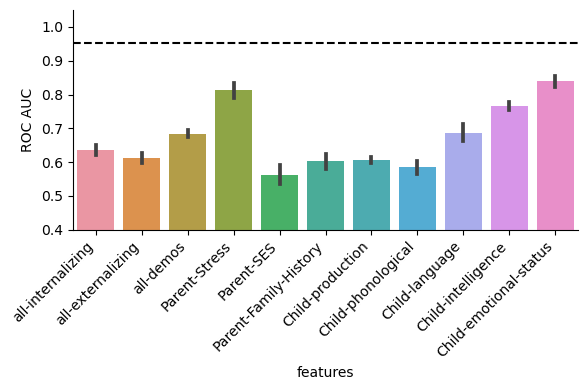

In [156]:

features = ['all-demos', 'Parent-Family-History', 'all-externalizing', 'all-internalizing',
       'Child-language', 'Child-phonological', 
       'Child-emotional-status', 'Parent-Stress', 'Child-production',
       'Child-intelligence', 'Parent-SES']

default_params.update({'Sex': ['male_female'],
                        'feature_threshold': ['top_5_selected_features'],
                         'DX': ['reading (all combord.)'],
                         'readers': ['all'],
                         'data': ['data', 'null'],
                         'features': features
                        })

# filter dataframe
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

plot_bar(df=df_filter, x='features', hue=None, plot_null=False)

default_params.update({'data': ['data'],
                         'features': ['Child-reading']
                        })

# filter dataframe
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

# plot reading model
plt.axhline(y=df_filter['roc_auc_score'].mean(), color='k', linestyle='--')

# fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-data-null-assessments.png'), bbox_inches='tight')


<Axes: xlabel='features', ylabel='ROC AUC'>

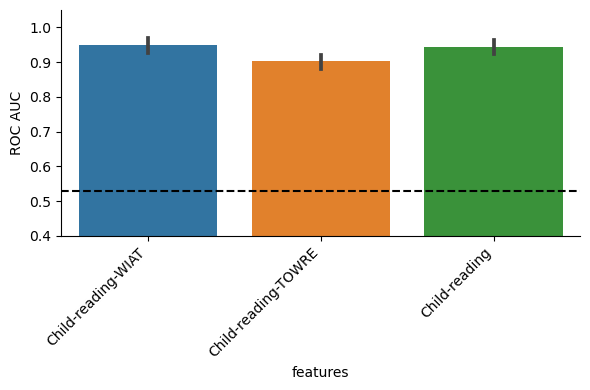

In [160]:

default_params.update({'Sex': ['male_female'],
                       'data': ['data', 'null'],
                       'readers': ['all'],
                       'feature_threshold': ['selected_all'],
                        'DX': ['reading (all combord.)'],
                        'features': ['Child-reading', 'Child-reading-TOWRE', 'Child-reading-WIAT']
                        })

# filter dataframe
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

plot_bar(df=df_filter, x='features')

# fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-data-null-assessments.png'), bbox_inches='tight')


<Axes: xlabel='DX', ylabel='ROC AUC'>

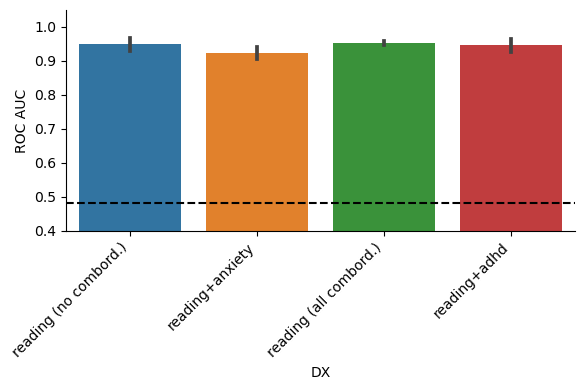

In [142]:


default_params.update({'Sex': ['male_female'],
                       'readers': ['all'],
                       'feature_threshold': ['top_5_selected_features'],
                        'DX': ['reading (all combord.)', 'reading (no combord.)', 'reading+adhd', 'reading+anxiety'],
                        'features': ['Child-reading']
                        })

# filter dataframe
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

plot_bar(df=df_filter, x='DX', hue=None)

# fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-data-null-assessments.png'), bbox_inches='tight')


<Axes: xlabel='DX', ylabel='ROC AUC'>

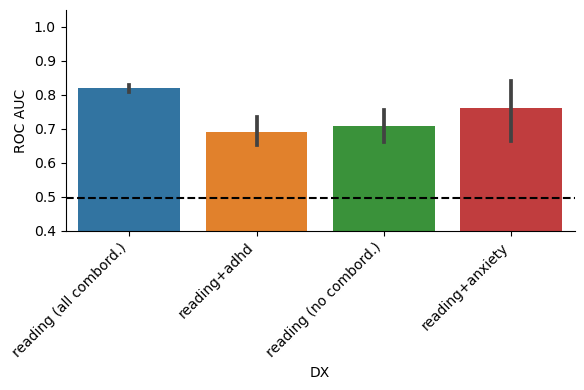

In [138]:


default_params.update({'Sex': ['male_female'],
                       'readers': ['all'],
                       'feature_threshold': ['selected_all'],
                        'DX': ['reading (all combord.)', 'reading (no combord.)', 'reading+adhd', 'reading+anxiety'],
                        'features': ['Child-emotional-status']
                        })

# filter dataframe
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

plot_bar(df=df_filter, x='DX', hue=None)

# fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-data-null-assessments.png'), bbox_inches='tight')


<Axes: ylabel='ROC AUC'>

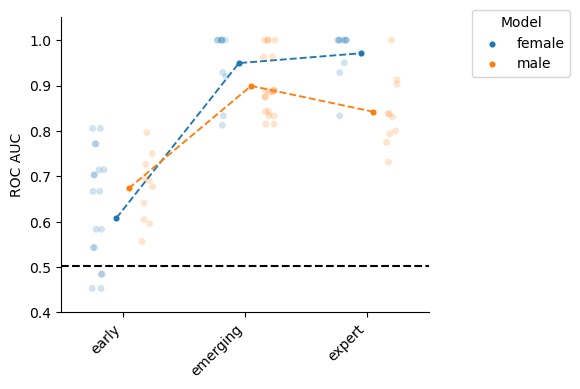

In [121]:
# default parameters

default_params.update({'Sex': ['male', 'female'],
                        'readers': ['early', 'emerging', 'expert'],
                        'feature_threshold': ['top_5_selected_features'],
                        'DX': ['reading (all combord.)'],
                        'features': ['Child-emotional-status']
                        })

# filter dataframe
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

plot_line(df=df_filter.sort_values(by=['readers']), x='readers', hue='Sex')

# fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-data-null-assessments.png'), bbox_inches='tight')


<Axes: ylabel='ROC AUC'>

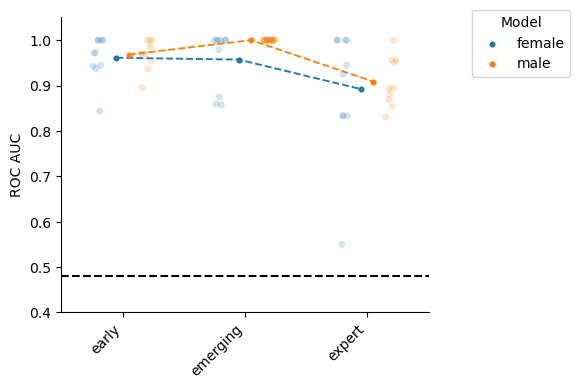

In [122]:
# default parameters

default_params.update({'Sex': ['male', 'female'],
                        'readers': ['early', 'emerging', 'expert'],
                        'feature_threshold': ['top_5_selected_features'],
                        'DX': ['reading (all combord.)'],
                        'features': ['Child-reading']
                        })

# filter dataframe
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

plot_line(df=df_filter.sort_values(by=['readers']), x='readers', hue='Sex')

# fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-data-null-assessments.png'), bbox_inches='tight')


<Axes: xlabel='DX', ylabel='ROC AUC'>

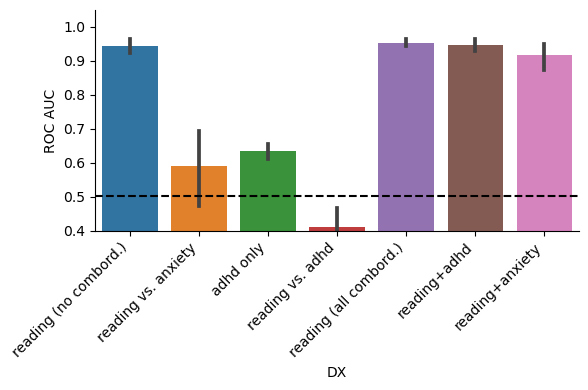

In [123]:

dx = ['reading (all combord.)', 
      'reading (no combord.)', 
      'reading+adhd', 
      'reading+anxiety',
      'adhd only',
      'reading vs. anxiety',
      'reading vs. adhd']

default_params.update({'DX': dx,
                       'features': ['Child-reading'],
                       'readers': ['all'],
                       'feature_threshold': ['selected_all'],
                       'Sex': ['male_female'],
                        })

# filter dataframe
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

plot_bar(df=df_filter, x='DX')

# fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-data-null-assessments.png'), bbox_inches='tight')


In [124]:
summary['Gender'].value_counts()

reading (all combord.)    600
reading (no combord.)     400
reading+adhd              400
reading+anxiety           200
Name: Gender, dtype: int64

<Axes: ylabel='ROC AUC'>

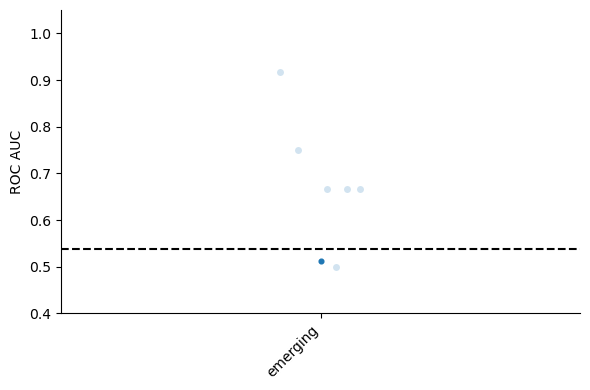

In [125]:
default_params = {'clf': ['RandomForestClassifier'],
 'data': ['data', 'null'],
 'feature_threshold': ['top_5_selected_features'],
 'readers': ['early', 'emerging', 'expert'],
 'Sex': ['male_female'],
 'features': ['parent-internalizing'],
 'Gender': ['reading+anxiety']
 }

# filter dataframe
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

plot_line(df=df_filter.sort_values(by='readers'), x='readers')